In [62]:
import pandas as pd
import numpy as np

In [63]:
df = pd.read_excel("dataset.xlsx")

In [64]:
df.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,Home.Away.Country,Home.Away.Region,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,Away,Home,1,NaN,1,0.651053,0.009442,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,Away,Away,1,NaN,1,1.323627,0.021757,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,Away,Away,1,NaN,0,2.586431,0.043924,0.574628,227.97333,0.654078,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,Away,Away,1,NaN,1,0.864872,0.013547,0.672746,178.45660,0.119194,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,Away,Away,1,NaN,0,0.931014,0.018473,0.733959,182.83057,0.323643,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [65]:
df.shape

(648, 30)

In [66]:
df.dtypes

,0
Unnamed: 0,int64
Year,int64
Country,object
Region,object
Artist,object
Song,object
Artist.gender,object
Group.Solo,object
Place,int64
Points,int64


In [67]:
df.columns

Index(['Unnamed: 0', 'Year', 'Country', 'Region', 'Artist', 'Song',
       'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country',
       'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English',
       'Song.Quality', 'Normalized.Points', 'energy', 'duration',
       'acousticness', 'danceability', 'tempo', 'speechiness', 'key',
       'liveness', 'time_signature', 'mode', 'loudness', 'valence',
       'Happiness'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [69]:
numerical_cols= df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)
categorical_cols= df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Unnamed: 0', 'Year', 'Place', 'Points', 'Is.Final',
       'Semi.Final.Number', 'Song.In.English', 'Song.Quality',
       'Normalized.Points', 'energy', 'duration', 'acousticness',
       'danceability', 'tempo', 'speechiness', 'key', 'liveness',
       'time_signature', 'mode', 'loudness', 'valence', 'Happiness'],
      dtype='object')
Index(['Country', 'Region', 'Artist', 'Song', 'Artist.gender', 'Group.Solo',
       'Home.Away.Country', 'Home.Away.Region'],
      dtype='object')


In [70]:
df.isna().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


In [71]:
df['Artist.gender'].value_counts()

,count
Artist.gender,
Female,101
Male,94
Both,31


In [72]:
df['Group.Solo'].value_counts()

,count
Group.Solo,
Solo,153
Group,73


In [73]:
df['Artist.gender']= df['Artist.gender'].fillna(df['Artist.gender'].mode()[0])
df['Group.Solo']= df['Group.Solo'].fillna(df['Group.Solo'].mode()[0])

In [74]:
df['loudness']

,loudness
0,-9.082
1,-6.059
2,-8.655
3,-4.536
4,-4.427
...,...
643,-3.223
644,NaN
645,NaN
646,-4.891


In [75]:
missing_cols = df.columns[df.isnull().sum() > 0]
print(missing_cols)

Index(['Semi.Final.Number', 'energy', 'duration', 'acousticness',
       'danceability', 'tempo', 'speechiness', 'key', 'liveness',
       'time_signature', 'mode', 'loudness', 'valence', 'Happiness'],
      dtype='object')


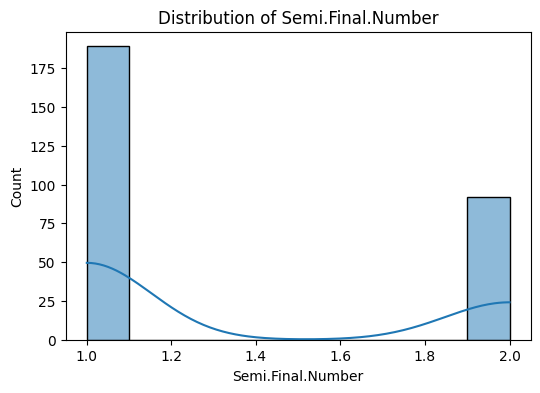

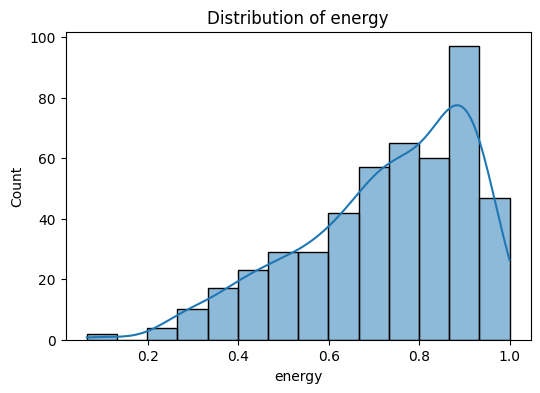

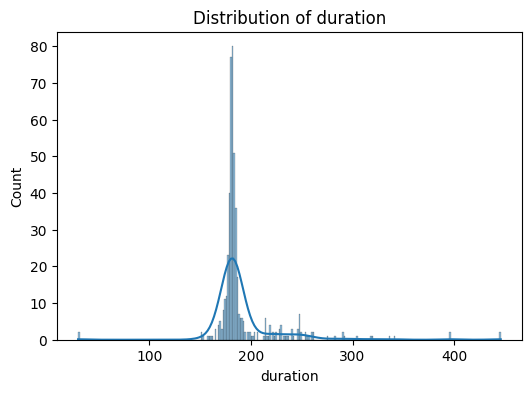

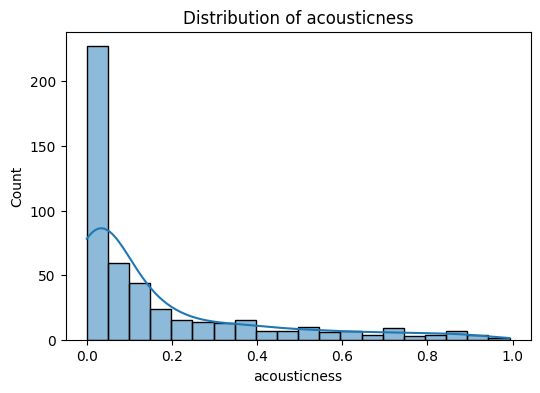

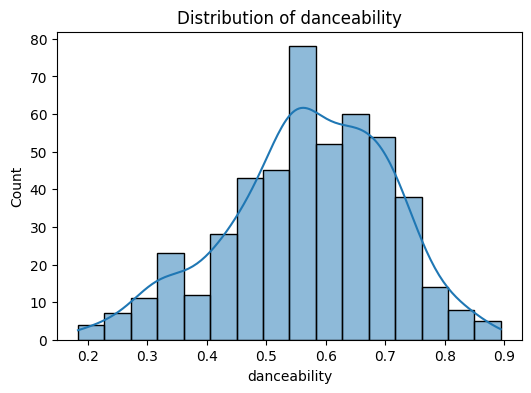

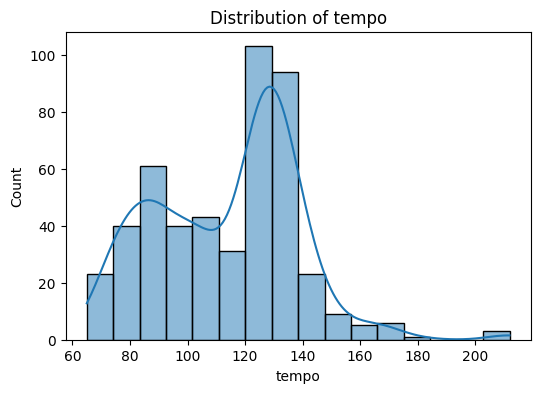

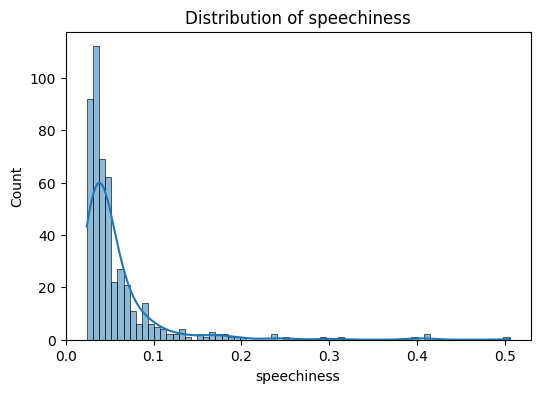

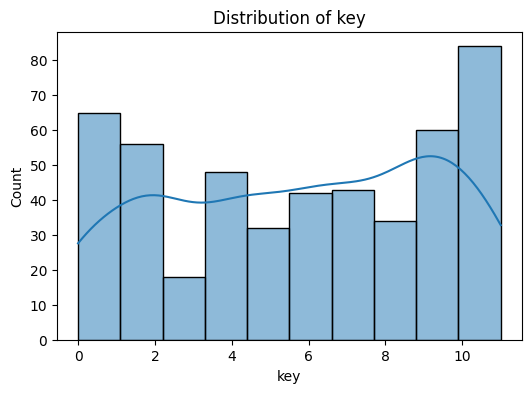

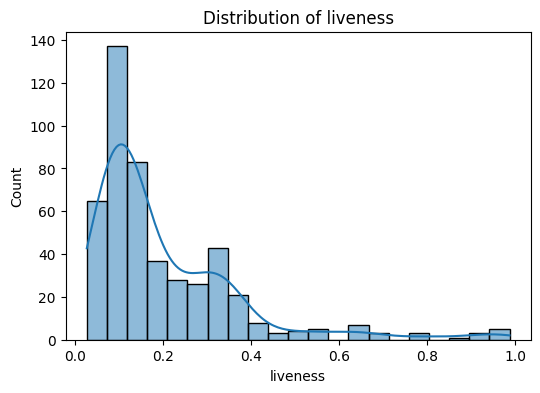

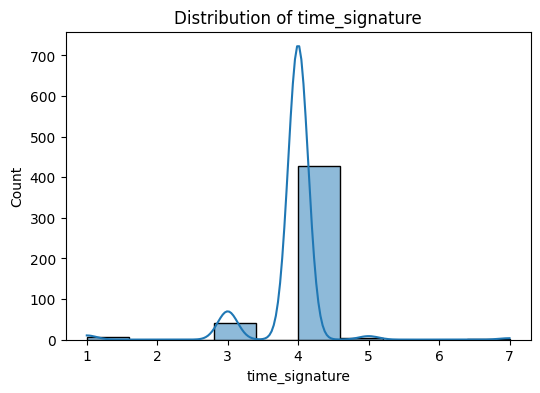

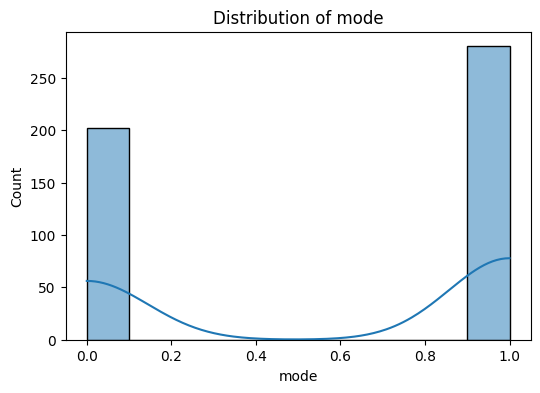

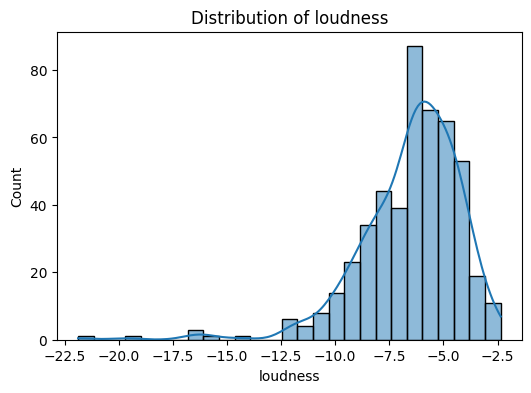

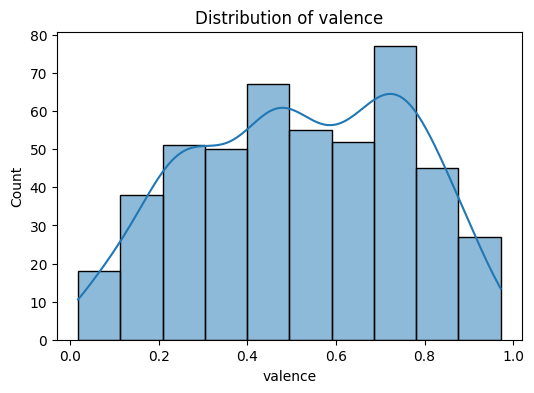

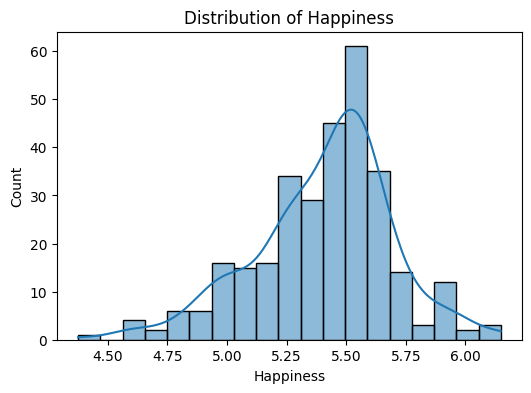

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in missing_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

filling the missing value according to the distribution

In [77]:
normal_dist = ['Happiness', 'valence', 'mode', 'key', 'tempo', 'danceability']
df[normal_dist] = df[normal_dist].fillna(df[normal_dist].mean())

In [78]:
skew_dist = ["loudness",'time_signature','liveness','speechiness','acousticness','duration','energy','Semi.Final.Number']
df[skew_dist]= df[skew_dist].fillna(df[skew_dist].median())

In [79]:
df.isna().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,0
Place,0
Points,0


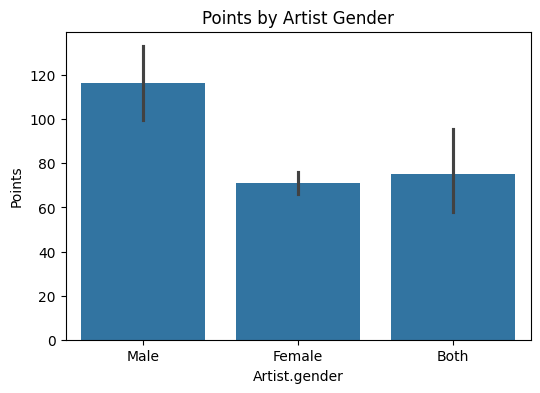

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x='Artist.gender', y='Points', data=df)
plt.title("Points by Artist Gender")
plt.show()

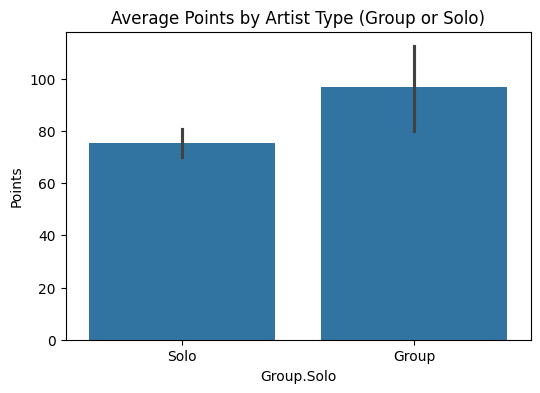

In [81]:
plt.figure(figsize=(6,4))
sns.barplot(x='Group.Solo', y='Points', data=df)
plt.title("Average Points by Artist Type (Group or Solo)")
plt.show()

In [82]:
df.head(3)

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,Home.Away.Country,Home.Away.Region,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,Away,Home,1,1.0,1,0.651053,0.009442,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,Away,Away,1,1.0,1,1.323627,0.021757,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,Away,Away,1,1.0,0,2.586431,0.043924,0.574628,227.97333,0.654078,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762


In [83]:
corr_matrix = df[numerical_cols].corr()

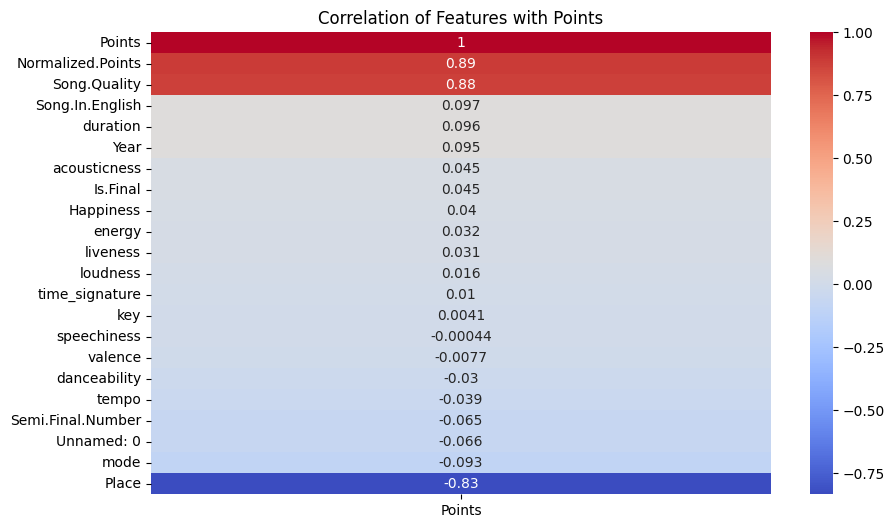

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix[['Points']].sort_values(by='Points', ascending=False),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation of Features with Points")
plt.show()

In [85]:
drop_cols = ['Unnamed: 0', 'Normalized.Points', 'Song.Quality', 'Place', 'Song', 'Artist', 'Country','mode','Semi.Final.Number']
df = df.drop(columns=drop_cols)

In [86]:
df.columns

Index(['Year', 'Region', 'Artist.gender', 'Group.Solo', 'Points',
       'Home.Away.Country', 'Home.Away.Region', 'Is.Final', 'Song.In.English',
       'energy', 'duration', 'acousticness', 'danceability', 'tempo',
       'speechiness', 'key', 'liveness', 'time_signature', 'loudness',
       'valence', 'Happiness'],
      dtype='object')

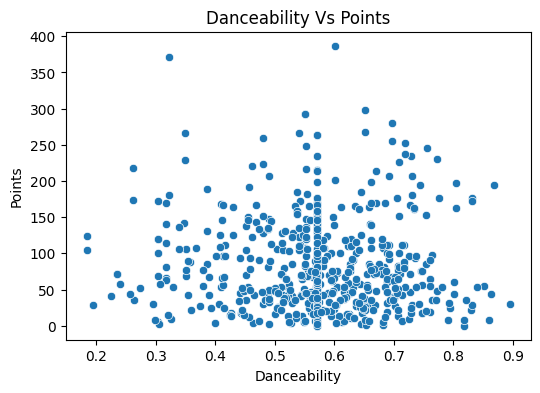

In [87]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='danceability', y='Points', data=df)

plt.title("Danceability Vs Points")
plt.xlabel("Danceability")
plt.ylabel("Points")

plt.show()

it shows no strong relationship most points are inthe 0.5 danceability

In [88]:
df.head(2)

,Year,Region,Artist.gender,Group.Solo,Points,Home.Away.Country,Home.Away.Region,Is.Final,Song.In.English,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,loudness,valence,Happiness
0,2009,Former Socialist Bloc,Male,Solo,23,Away,Home,1,1,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,-9.082,0.482059,6.148232
1,2009,Independent,Female,Group,53,Away,Away,1,1,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,-6.059,0.426209,5.141887


In [89]:
df.dtypes

,0
Year,int64
Region,object
Artist.gender,object
Group.Solo,object
Points,int64
Home.Away.Country,object
Home.Away.Region,object
Is.Final,int64
Song.In.English,int64
energy,float64


In [90]:
df_encoded = pd.get_dummies(df, columns=['Region','Artist.gender','Group.Solo','Home.Away.Country','Home.Away.Region'], drop_first=True)

In [91]:
df_encoded.head()

,Year,Points,Is.Final,Song.In.English,energy,duration,acousticness,danceability,tempo,speechiness,key,liveness,time_signature,loudness,valence,Happiness,Region_Former Yugoslavia,Region_Independent,Region_Scandinavia,Region_Western Europe,Artist.gender_Female,Artist.gender_Male,Group.Solo_Solo,Home.Away.Country_Home,Home.Away.Region_Home
0,2009,23,1,1,0.678258,183.18476,0.563170,0.598360,102.984,0.027817,9.0,0.078643,3.0,-9.082,0.482059,6.148232,False,False,False,False,False,True,True,False,True
1,2009,53,1,1,0.794093,179.87873,0.068711,0.604542,105.972,0.024996,8.0,0.084805,4.0,-6.059,0.426209,5.141887,False,True,False,False,True,False,False,False,False
2,2009,107,1,0,0.574628,227.97333,0.654078,0.367344,124.005,0.043751,1.0,0.923905,4.0,-8.655,0.292870,5.069762,False,False,False,True,True,False,True,False,False
3,2009,33,1,1,0.672746,178.45660,0.119194,0.513202,128.021,0.034855,10.0,0.143708,4.0,-4.536,0.206493,5.502692,False,False,True,False,True,False,True,False,False
4,2009,45,1,0,0.733959,182.83057,0.323643,0.590592,116.107,0.032406,1.0,0.079322,4.0,-4.427,0.344541,5.406843,True,False,False,False,False,False,False,False,False


In [92]:
X = df_encoded.drop('Points', axis=1)
y = df_encoded['Points']

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [96]:
y_pred = model.predict(X_test)

In [97]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
mse = mean_squared_error(y_test,y_pred)
print("Mean squared Error:",mse)
r2_score = r2_score(y_test,y_pred)
print("r2 score:", r2_score)


Mean Absolute Error: 43.75985893997719
Mean squared Error: 3183.3797826171917
r2 score: 0.2160306704577616


MAE is the average difference between predicted points and actual points. here it showing an average of 43 points difference

In [98]:
import pickle
with open('model.pkl','wb') as f:
  pickle.dump(df_encoded,f)